In [1]:
# libraries
import random
import numpy as np
import matplotlib.pyplot as plt
import time

# sorting functions from the source files
from src.bubble_sort import bubble_sort
from src.insertion_sort import insertion_sort
from src.selection_sort import selection_sort
from src.merge_sort import merge_sort
from src.quick_sort import quick_sort

# Sorting Algorithms: Mathematical Analysis and Python Implementations

**Math Concepts for Developers – Exam Project**

Author: Plamen Panayotov

---

Sorting algorithms are fundamental components of computer science and software engineering. They are used in databases, search engines, operating systems, and many other computational systems.

This project explores several classical sorting algorithms through both **mathematical analysis** and **Python implementations**. The study focuses on:

- algorithm design principles
- time complexity analysis
- empirical performance evaluation
- visualization of algorithm behavior

The algorithms examined include:

- Bubble Sort
- Selection Sort
- Insertion Sort
- Merge Sort
- Quick Sort

Both theoretical complexity and experimental performance will be analyzed.


## 1. Introduction

Sorting is the process of rearranging elements of a list into a specific order, typically ascending or descending.

Sorting algorithms are a classic subject in algorithm analysis because they illustrate fundamental ideas such as:

- algorithmic complexity
- recursion
- divide-and-conquer strategies
- trade-offs between simplicity and efficiency

In many applications, sorting is a prerequisite step for more complex operations such as searching, data analysis, and database indexing.

In this project we will:

1. Implement several well-known sorting algorithms in Python
2. Analyze their **time complexity**
3. Compare their **theoretical efficiency**
4. Perform **empirical experiments** using randomly generated datasets
5. Visualize performance using Python libraries

## 2. Mathematical Definition of Sorting

Let us define sorting formally.

Given a sequence:

$
A = [a_1, a_2, a_3, ..., a_n]
$

Sorting transforms the sequence into a new sequence:

$
A' = [a'_1, a'_2, a'_3, ..., a'_n]
$

such that:

$
a'_1 \leq a'_2 \leq a'_3 \leq ... \leq a'_n
$

and the elements of $A'$ are a **permutation** of the elements of $A$.

This means the sorted array contains exactly the same elements as the original array, only arranged in order.

## 3. Time Complexity

Algorithm efficiency is usually measured using **asymptotic complexity**.

The most common notation used is **Big-O notation**.

### Big-O Definition

A function $f(n)$ is said to be $O(g(n))$ if there exist constants $c > 0$ and $n_0$ such that:

$
f(n) \leq c \cdot g(n)
$

for all $n \ge n_0$.

In algorithm analysis, this describes how the runtime of an algorithm grows relative to input size.

### Common complexities

| Complexity | Example |
|------------|--------|
| $O(1)$ | Constant time |
| $O(\log n)$ | Binary search |
| $O(n)$ | Linear scan |
| $O(n \log n)$ | Efficient sorting algorithms |
| $O(n^2)$ | Simple quadratic algorithms |

In [2]:
# helper function used for testing ( our dataset )
def generate_random_list(n):
    """Generate a list of n random integers."""
    return [random.randint(0, 10000) for _ in range(n)]

In [3]:
# helper function we will use to visualize execution times
def visualize_exec_time(sizes, times, algo_name):
    plt.plot(sizes, times, marker="o")

    plt.xlabel("Input Size (n)")
    plt.ylabel("Execution Time (seconds)")
    plt.title(f"{algo_name} Runtime Growth")
    
    plt.grid(True)
    
    plt.show()

## 4. Bubble Sort

Bubble Sort is one of the simplest sorting algorithms.

The algorithm repeatedly steps through the list, compares adjacent elements, and swaps them if they are in the wrong order.

This process continues until no swaps are needed.

### Time Complexity

Worst case:

$
O(n^2)
$

Average case:

$
O(n^2)
$

Best case:

$
O(n)
$

The algorithm is inefficient for large datasets but useful for educational purposes because of its simplicity.

### Demo

In [4]:
# we create an unsorted list of 10 elements
unsorted_list = generate_random_list(10)
unsorted_list

[6751, 4208, 6612, 7931, 7915, 4821, 1268, 1289, 6224, 7770]

In [5]:
# lets sort it with our ubble sort function now
sorted_list = bubble_sort(unsorted_list)
sorted_list

[1268, 1289, 4208, 4821, 6224, 6612, 6751, 7770, 7915, 7931]

The example above confirms that the implementation correctly sorts the list.

However, correctness alone is not sufficient. The key question is how the algorithm performs as the input size increases.

In the following experiment we measure the runtime of Bubble Sort for lists of increasing size and visualize the growth of execution time.

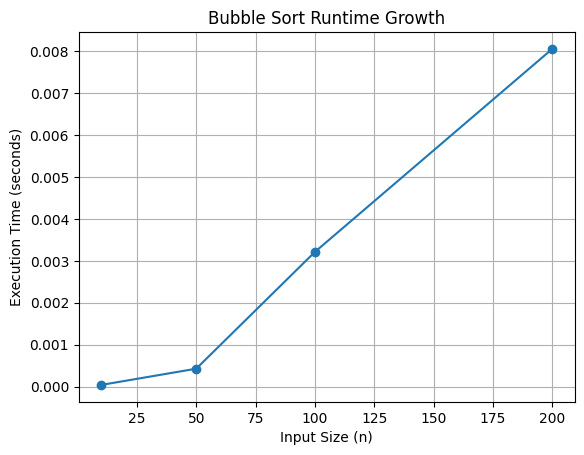

In [6]:
# lets compare lists with different sizes
sizes = [10, 50, 100, 200]
times = []

for size in sizes:
    unsort_list = generate_random_list(size)

    start = time.time()
    bubble_sort(unsort_list)
    end = time.time()

    times.append(end - start)
    
visualize_exec_time(sizes, times, "Bubble Sort")

### Bubble sort Conclusion

The experimental results confirm the theoretical expectations of Bubble Sort's time complexity.

As the size of the input array increases, the execution time grows rapidly. This behavior is consistent with the theoretical worst-case and average-case complexity of:

$
O(n^2)
$

This quadratic growth occurs because Bubble Sort performs repeated pairwise comparisons between elements. In the worst case, the algorithm must perform approximately:

$
\frac{n(n-1)}{2}
$

comparisons.

Even for moderately sized arrays, the execution time increases significantly compared to more efficient sorting algorithms. For this reason, Bubble Sort is rarely used in production systems and is primarily valuable for educational purposes due to its conceptual simplicity.

In the following sections, we will examine more efficient algorithms such as **Insertion Sort**, **Merge Sort**, and **Quick Sort**, and compare their performance to Bubble Sort.

## 5. Insertion Sort

Insertion Sort is another simple comparison-based sorting algorithm.  
It works similarly to the way people sort playing cards in their hands.

The algorithm builds the sorted array one element at a time by inserting
each new element into its correct position among the previously sorted elements.

### Time Complexity

Insertion Sort has different performance depending on the initial order of the array.

**Worst case**

$
O(n^2)
$

This occurs when the input array is sorted in reverse order. In this case, each element must be compared with all previously sorted elements and shifted accordingly.

**Best case**

$
O(n)
$

This occurs when the array is already sorted. In this situation, each element only requires one comparison, since it is already greater than the element before it.

**Average case**

$
O(n^2)
$

For randomly ordered data, the number of comparisons and shifts grows approximately proportional to \(n^2\).

Although its worst-case complexity is quadratic, Insertion Sort performs significantly better than Bubble Sort when the input data is already partially sorted.

### Demo

In [7]:
# we will use the same unordered list we previously generated
unsorted_list

[6751, 4208, 6612, 7931, 7915, 4821, 1268, 1289, 6224, 7770]

In [8]:
# now to test our source function
sorted_list = insertion_sort(unsorted_list)
sorted_list

[1268, 1289, 4208, 4821, 6224, 6612, 6751, 7770, 7915, 7931]

Now for the runtime visualization (we can take the liberty to add bigger sizes to this list):

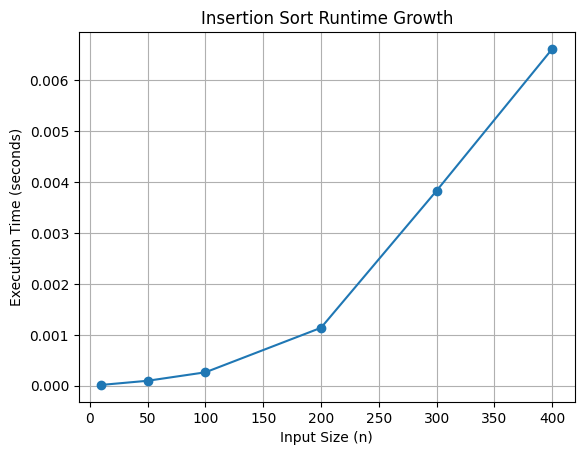

In [9]:
sizes = [10, 50, 100, 200, 300, 400]
times = [] 

for n in sizes:
    unsort_list = generate_random_list(n)

    start = time.time()
    insertion_sort(unsort_list)
    end = time.time()

    times.append(end - start)

visualize_exec_time(sizes, times, "Insertion Sort")

### Insertion sort Conclusion

The empirical runtime growth of Insertion Sort is consistent with the theoretical analysis.

For randomly generated data, the runtime increases approximately quadratically as the input size grows. This corresponds to the average-case complexity of:

$
O(n^2)
$

However, Insertion Sort performs significantly better than Bubble Sort when the input data is already nearly sorted. This makes it useful in practice for small datasets or as a subroutine within more complex algorithms.

## 6. Selection Sort

Selection Sort is another comparison-based sorting algorithm. Instead of repeatedly swapping adjacent elements or inserting elements into a sorted portion, Selection Sort works by repeatedly selecting the smallest remaining element and placing it in its correct position.

The algorithm divides the list into two regions:

- a sorted portion at the beginning
- an unsorted portion containing the remaining elements

At each step, the smallest element from the unsorted region is selected and swapped with the first element of that region.

### Time Complexity

Selection Sort performs a fixed number of comparisons regardless of the initial ordering of the array.

Worst case:

$
O(n^2)
$

Average case:

$
O(n^2)
$

Best case:

$
O(n^2)
$

Unlike Insertion Sort, Selection Sort does not benefit from already sorted data because it must still scan the remaining unsorted elements to find the minimum value.

The number of comparisons performed by Selection Sort is approximately:

$
\frac{n(n-1)}{2}
$

This leads to quadratic growth in execution time as the input size increases.

### Demo

In [10]:
# that one same unsorted list
unsorted_list

[6751, 4208, 6612, 7931, 7915, 4821, 1268, 1289, 6224, 7770]

In [11]:
# we perform the sanity check to make sure the algorithm from the source works
sorted_list = selection_sort(unsorted_list)
sorted_list

[1268, 1289, 4208, 4821, 6224, 6612, 6751, 7770, 7915, 7931]

Vizualization again! This time we will skip on adding more sizes.

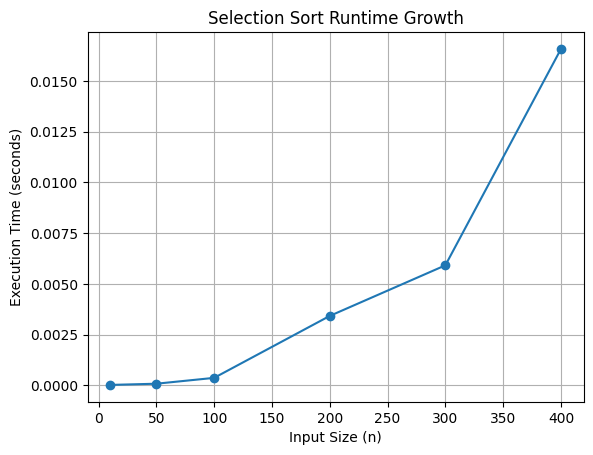

In [12]:
sizes = [10, 50, 100, 200, 300, 400]
times = [] 

for n in sizes:
    unsort_list = generate_random_list(n)

    start = time.time()
    selection_sort(unsort_list)
    end = time.time()

    times.append(end - start)

visualize_exec_time(sizes, times, "Selection Sort")

### Selection Sort Conclusion

The experimental results confirm that Selection Sort exhibits quadratic runtime growth as the input size increases.

Unlike Insertion Sort, Selection Sort performs the same number of comparisons regardless of the initial ordering of the data. This means that even if the array is already sorted, the algorithm still performs the full set of comparisons.

Although Selection Sort is simple and easy to understand, its $(O(n^2))$ time complexity makes it inefficient for large datasets. As a result, it is mostly used for educational purposes rather than real-world applications.

## 7. Merge Sort

Merge Sort is a sorting algorithm based on the **divide and conquer** strategy.

The main idea is to repeatedly divide the input array into smaller subarrays until each subarray contains a single element. These small arrays are then merged together in sorted order to produce the final sorted array.

The algorithm works in three main steps:

1. Divide the array into two halves
2. Recursively sort each half
3. Merge the two sorted halves

### Time Complexity

Merge Sort has a predictable and efficient runtime.

Worst case:

$
O(n \log n)
$

Average case:

$
O(n \log n)
$

Best case:

$
O(n \log n)
$

The reason for this complexity comes from the recursive structure of the algorithm.

At each level of recursion the array is divided in half, producing approximately:

$
\log_2 n
$

levels of recursion.

At every level, the merge operation processes all elements in the array, requiring:

$
O(n)
$

work.

Combining these results gives the total time complexity:

$
O(n \log n)
$

### Demo

In [13]:
# sanity check again
sorted_list = merge_sort(unsorted_list)
sorted_list

[1268, 1289, 4208, 4821, 6224, 6612, 6751, 7770, 7915, 7931]

Since this algorithm is much more optimized, we can add even more sizes for visualization!

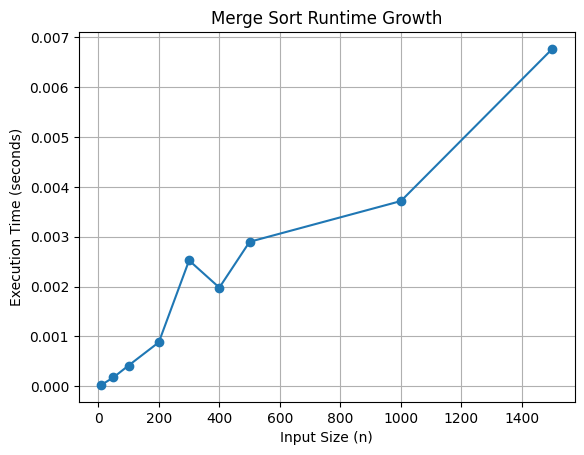

In [14]:
sizes = [10, 50, 100, 200, 300, 400, 500, 1000, 1500]
times = [] 

for n in sizes:
    unsort_list = generate_random_list(n)

    start = time.time()
    merge_sort(unsort_list)
    end = time.time()

    times.append(end - start)

visualize_exec_time(sizes, times, "Merge Sort")

### Merge Sort Conclusion

The experimental results demonstrate that Merge Sort grows significantly more slowly than the previously examined quadratic algorithms.

This behavior is consistent with the theoretical time complexity of:

$
O(n \log n)
$

Because the algorithm divides the input into smaller subproblems and merges them efficiently, it avoids the large number of comparisons performed by algorithms such as Bubble Sort, Insertion Sort, and Selection Sort.

Merge Sort is therefore much more suitable for sorting large datasets. However, it requires additional memory to store intermediate arrays during the merging process.

## 8. Quick Sort

Quick Sort is a highly efficient sorting algorithm that also uses the **divide and conquer** strategy.

Instead of splitting the array in half like Merge Sort, Quick Sort selects a **pivot element** and partitions the array so that:

- elements smaller than the pivot appear before it
- elements larger than the pivot appear after it

The algorithm then recursively applies the same process to the left and right partitions until the entire array is sorted.

### Time Complexity

Quick Sort has different performance depending on how balanced the partitions are during the sorting process.

Worst case:

$
O(n^2)
$

This occurs when the pivot repeatedly produces very unbalanced partitions (for example, if the array is already sorted and the first element is chosen as the pivot).

Average case:

$
O(n \log n)
$

Best case:

$
O(n \log n)
$

In practice, Quick Sort often performs faster than Merge Sort because it operates **in-place** and requires less additional memory.

### Demo

In [15]:
# sanity check
sorted_list = quick_sort(unsorted_list)
sorted_list

[1268, 1289, 4208, 4821, 6224, 6612, 6751, 7770, 7915, 7931]

Because this algorithm is efficient we can test larger sizes!

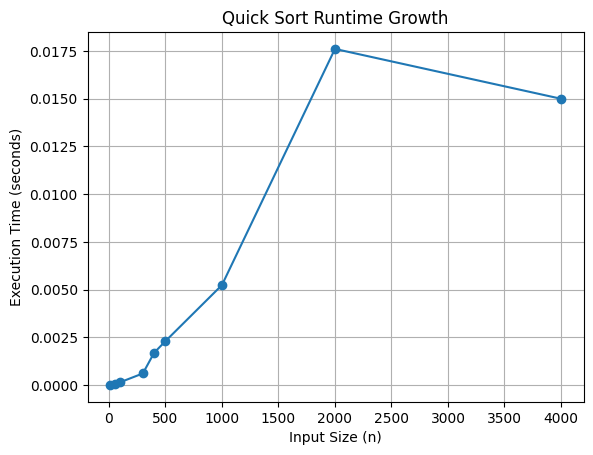

In [16]:
sizes = [10, 50, 100, 300, 400, 500, 1000, 2000, 4000]
times = []

for n in sizes:
    unsort_list = generate_random_list(n)

    start = time.time()
    quick_sort(unsort_list)
    end = time.time()

    times.append(end - start)

visualize_exec_time(sizes, times, "Quick Sort")

### Quick Sort Conclusion

The empirical results show that Quick Sort scales significantly better than the quadratic sorting algorithms examined earlier.

The observed runtime growth is consistent with the theoretical average-case complexity:

$
O(n \log n)
$

Quick Sort is widely used in practice because of its excellent average performance and low memory overhead. However, its worst-case complexity remains quadratic if poor pivot choices repeatedly produce unbalanced partitions.

In practice, modern implementations use randomized or median-based pivot selection to reduce the likelihood of worst-case behavior.

## 9. Final Algorithm Comparison

In the previous sections, each sorting algorithm was analyzed individually.  
To better understand their relative performance, we now compare all implemented algorithms under the same experimental conditions.

The following algorithms are included in the comparison:

- Bubble Sort
- Insertion Sort
- Selection Sort
- Merge Sort
- Quick Sort

Each algorithm will sort randomly generated lists of increasing size, and the execution time will be recorded. The results will then be visualized to highlight differences in performance and scalability.

In [17]:
algorithms = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Selection Sort": selection_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

sizes = [10, 50, 100, 200, 500, 1000, 2000]

results = {name: [] for name in algorithms}

In [18]:
for n in sizes:
    base_list = generate_random_list(n)

    for name, algorithm in algorithms.items():
        list_copy = base_list.copy()

        start = time.time()
        algorithm(list_copy)
        end = time.time()

        results[name].append(end - start)

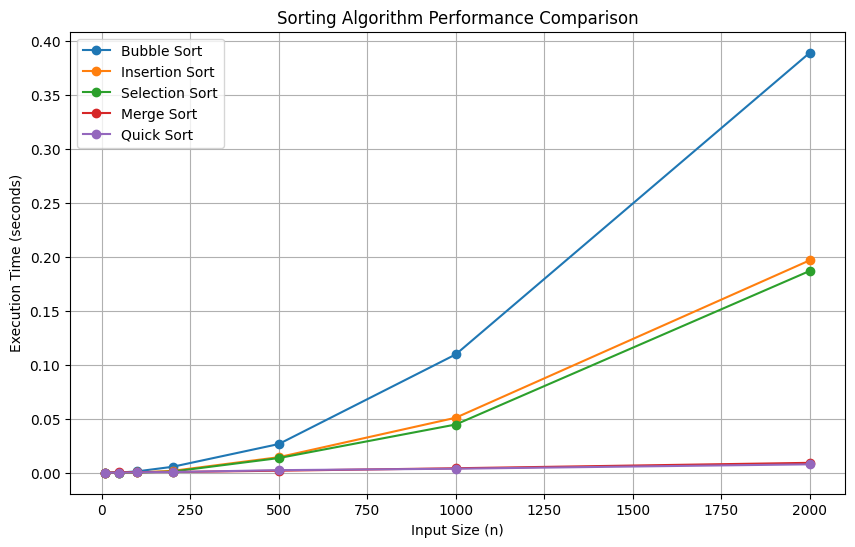

In [19]:
plt.figure(figsize=(10,6))

for name, times in results.items():
    plt.plot(sizes, times, marker="o", label=name)

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithm Performance Comparison")

plt.legend()
plt.grid(True)

plt.show()

### Comparative Analysis

The comparison graph clearly highlights the differences between quadratic and logarithmic sorting algorithms.

Bubble Sort, Insertion Sort, and Selection Sort exhibit **quadratic growth**:

$
O(n^2)
$

As the input size increases, their execution times grow rapidly.

In contrast, Merge Sort and Quick Sort demonstrate significantly better scalability, with time complexity:

$
O(n \log n)
$

These algorithms grow much more slowly and remain efficient even for larger datasets.

Although Quick Sort and Merge Sort share the same theoretical complexity, Quick Sort often performs slightly faster in practice due to its in-place operations and reduced memory usage.

Overall, the results confirm the importance of choosing efficient algorithms when working with large data sets.

### Mathematical Comparison

Sorting algorithms can be analyzed by counting the number of **element comparisons** required to sort a list of size \( n \).

For many simple sorting algorithms, the number of comparisons grows approximately according to the quadratic formula:

$
\frac{n(n-1)}{2}
$

This expression arises because each element must be compared with many other elements in the list.

#### Bubble Sort

In Bubble Sort, the number of comparisons in the worst case is:

$
\sum_{i=1}^{n-1} (n-i)
$

This simplifies to:

$
\frac{n(n-1)}{2}
$

which leads to the time complexity:

$
O(n^2)
$

#### Insertion Sort

Insertion Sort performs up to:

$
\sum_{i=1}^{n-1} i
$

comparisons in the worst case, which also simplifies to:

$
\frac{n(n-1)}{2}
$

#### Merge Sort

Merge Sort follows the recurrence relation:

$
T(n) = 2T\left(\frac{n}{2}\right) + O(n)
$

Using the **Master Theorem**, this recurrence solves to:

$
T(n) = O(n \log n)
$

#### Quick Sort

Quick Sort has the recurrence relation:

$
T(n) = T(k) + T(n-k-1) + O(n)
$

where \(k\) is the number of elements smaller than the pivot.

On average, the partition sizes are balanced, leading to:

$
T(n) = O(n \log n)
$

However, in the worst case:

$
T(n) = O(n^2)
$

### Complexity Summary

| Algorithm | Best Case | Average Case | Worst Case | Space Complexity |
|-----------|-----------|--------------|------------|------------------|
| Bubble Sort | $O(n)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ |
| Insertion Sort | $O(n)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ |
| Selection Sort | $O(n^2)$ | $O(n^2)$ | $O(n^2)$ | $O(1)$ |
| Merge Sort | $O(n \log n)$ | $O(n \log n)$ | $O(n \log n)$ | $O(n)$ |
| Quick Sort | $O(n \log n)$ | $O(n \log n)$ | $O(n^2)$ | $O(\log n)$ |

## 10. Conclusion

This project explored several classical sorting algorithms and analyzed their behavior from both theoretical and empirical perspectives.

The study demonstrated how mathematical complexity analysis translates into real-world performance differences. Algorithms with quadratic complexity, such as Bubble Sort, Insertion Sort, and Selection Sort, quickly become inefficient as the size of the dataset grows.

More advanced algorithms such as Merge Sort and Quick Sort, which operate with $O(n \log n)$ complexity, scale significantly better and are more suitable for large datasets.

Through implementation, experimentation, and visualization, this project highlights the importance of algorithm design and mathematical analysis in software development.

## 11. References

1. Cormen, T., Leiserson, C., Rivest, R., Stein, C.  
   *Introduction to Algorithms*, MIT Press  
   https://mitpress.mit.edu/9780262046305/introduction-to-algorithms/

2. Knuth, Donald.  
   *The Art of Computer Programming, Volume 3: Sorting and Searching*  
   https://www-cs-faculty.stanford.edu/~knuth/taocp.html

3. Python Documentation – Sorting HOWTO  
   https://docs.python.org/3/howto/sorting.html

4. Khan Academy – Sorting Algorithms  
   https://www.khanacademy.org/computing/computer-science/algorithms

5. GeeksforGeeks – Sorting Algorithms  
   https://www.geeksforgeeks.org/sorting-algorithms/